# The irreducible mass of black holes

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from scipy.stats import uniform  
import scipy.stats as stats
import scipy
from astroML import stats as astroMLstats
from sklearn.neighbors import KernelDensity
from tqdm import tqdm

%matplotlib inline
%config InlineBackend.figure_format='retina'

N=10000

Given a BH mass and spin(chi), we can compute the irreducible mass = mass*f(spin)

In [2]:
def f(chi):
    return (((1+(1-(chi**2))**(0.5))/2)**(0.5))

def irreducible(mass, chi):
    return mass*f(chi)

visualize f(spin)

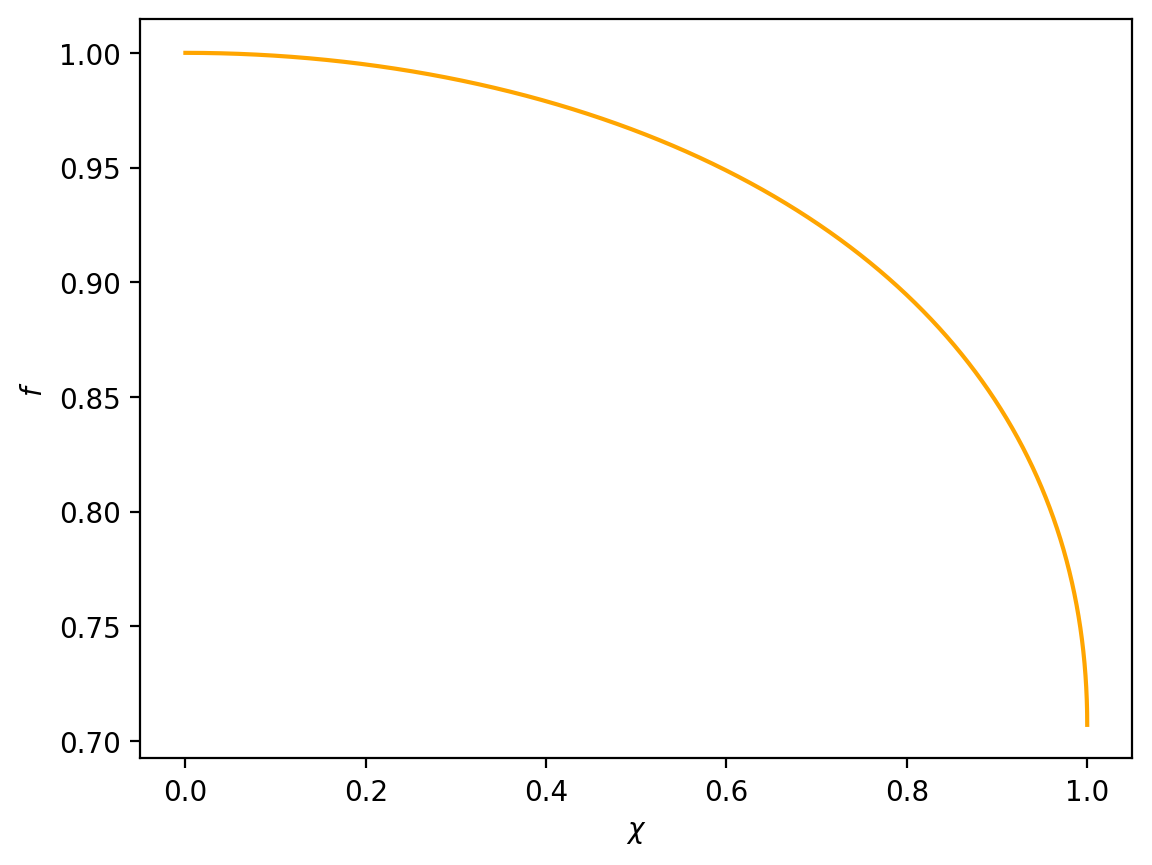

In [3]:
chi=np.linspace(0,1,N)
plt.plot(chi,f(chi), color='orange')
plt.xlabel('$\chi$')
plt.ylabel('$f$');

Suppose I have repeated measurements of M and spin: the mass is normally distributed with mean 1 and sigma 0.02, the spin is uniform between 0 and 1

In [4]:
mu=1
sigma=0.02

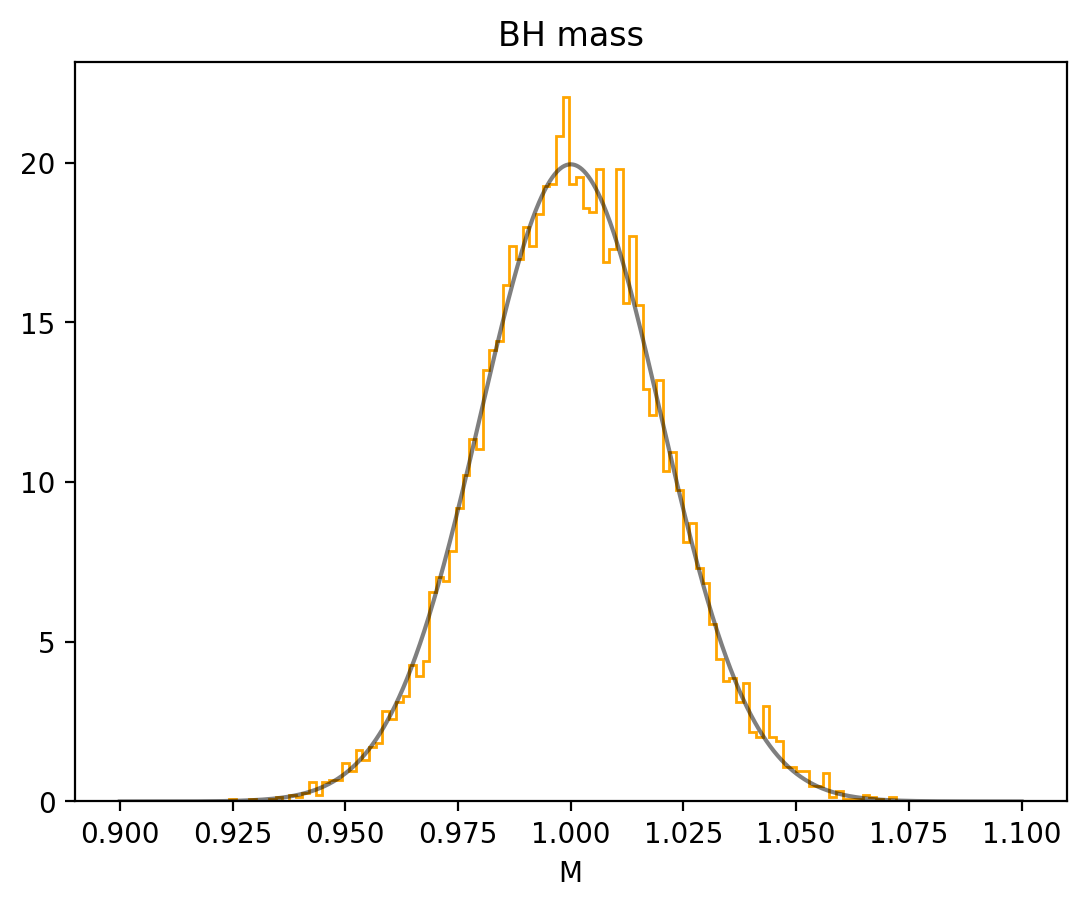

In [5]:
M=np.random.normal(loc=mu,scale=sigma,size=N)

plt.hist(M,density=True,histtype='step',bins=100,color='orange');

x = np.linspace(1-5*sigma,1+5*sigma,N)
m = scipy.stats.norm.pdf(x, mu, sigma)
plt.plot(x,m,alpha=0.5,color='k')

plt.xlabel('M')
plt.title('BH mass')
plt.show()

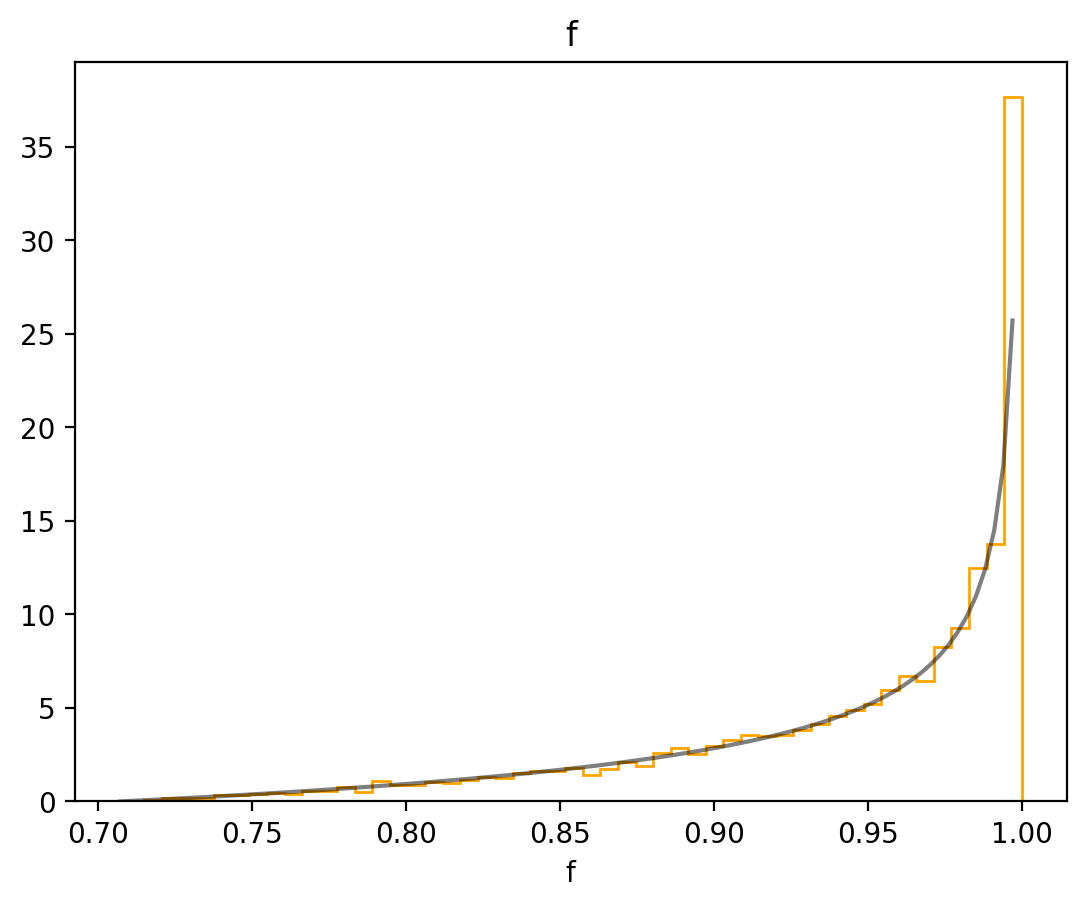

In [6]:
chi = np.random.uniform(0,1,N)

littlef = f(chi)
plt.hist(littlef,density=True,histtype='step',bins=50,color='orange')

F = np.linspace(1/2**0.5,1,100)[:-1]
pdff = 2*(2*F**2-1)/(1 - F**2)**0.5
plt.plot(F,pdff,alpha=0.5,color='k');

plt.xlabel('f')
plt.title('f')
plt.show()

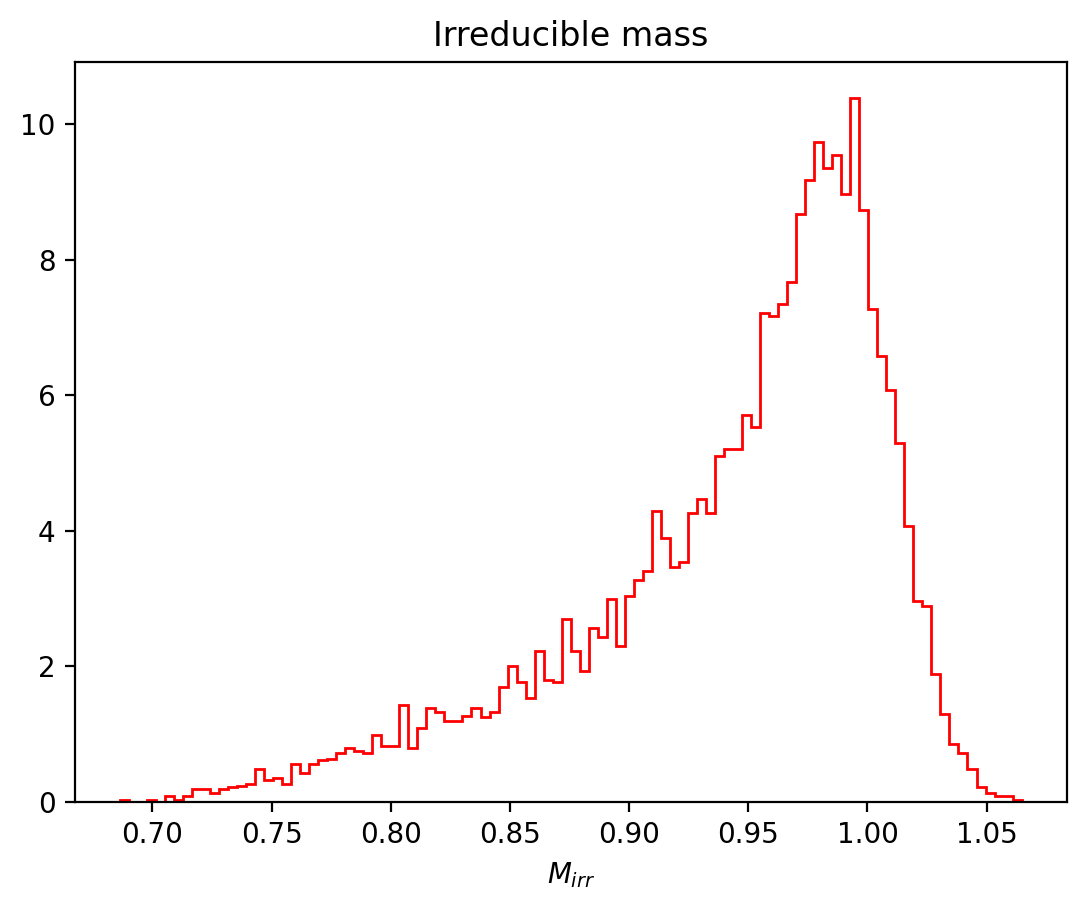

In [7]:
M_irr=irreducible(M,chi)

plt.hist(M_irr,bins=100,histtype='step',density=True, color='red')
plt.xlabel('$M_{irr}$')
plt.title('Irreducible mass');

Scott's rule and Freedman's rule for optimal bin width

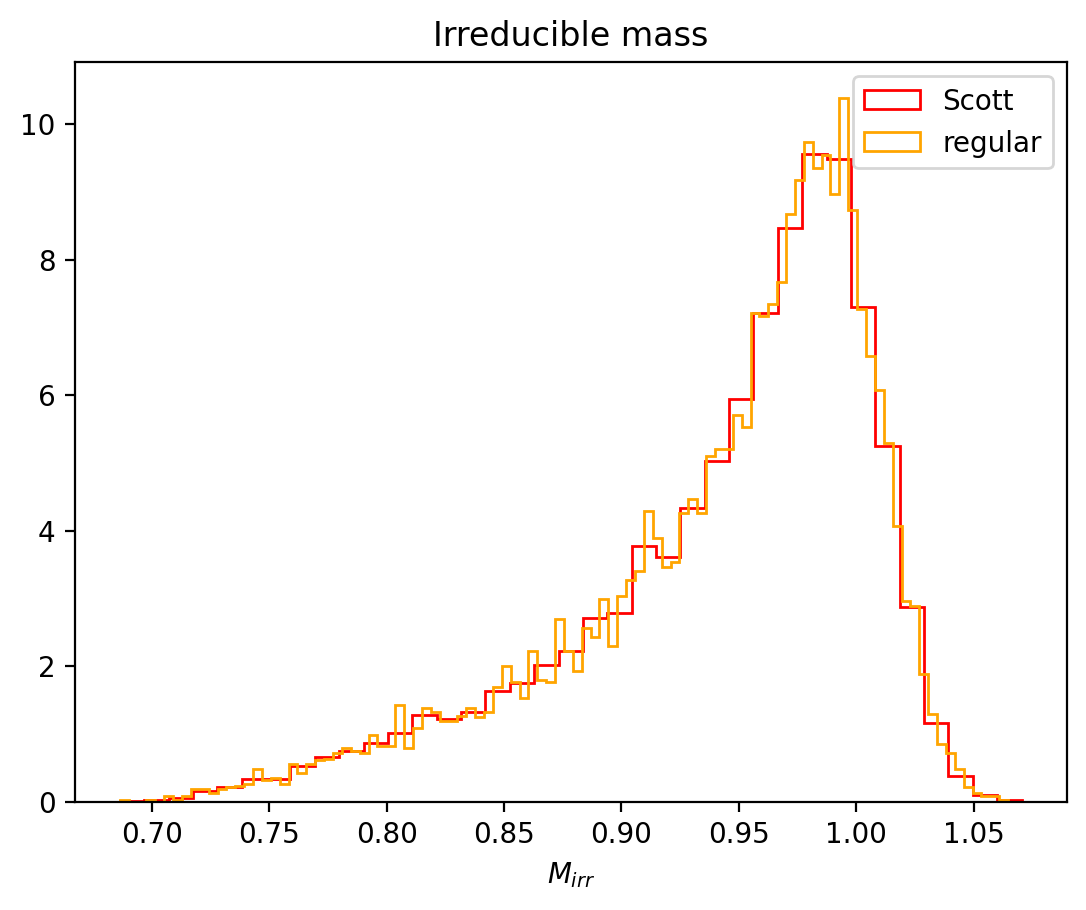

In [8]:
import astropy.visualization.hist

astropy.visualization.hist(M_irr, bins="scott", histtype="step",density=True, color='red', label='Scott')
plt.hist(M_irr,bins=100,histtype='step',density=True, color='orange',label='regular')
plt.xlabel('$M_{irr}$')
plt.title('Irreducible mass')
plt.legend();

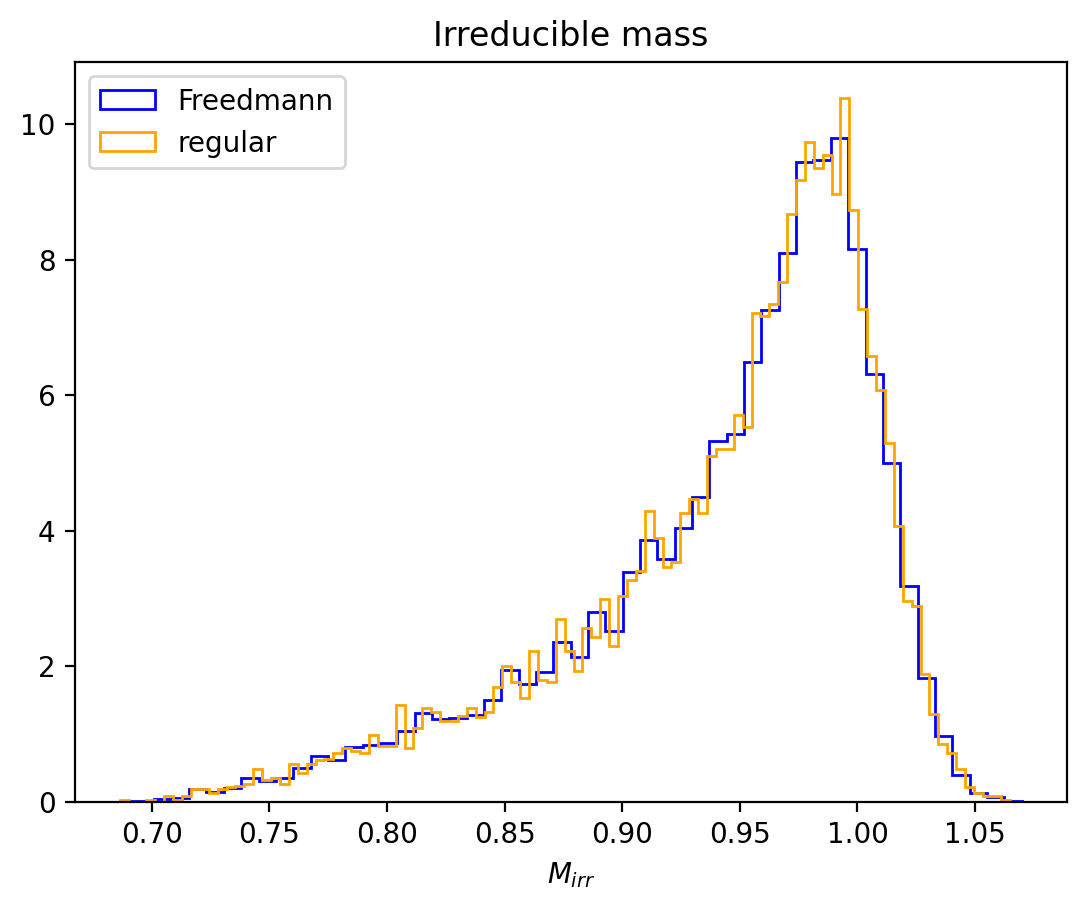

In [9]:
astropy.visualization.hist(M_irr, bins="freedman", histtype="step",density=True, color='blue', label='Freedmann')
plt.hist(M_irr,bins=100,histtype='step',density=True, color='orange',label='regular')
plt.xlabel('$M_{irr}$')
plt.title('Irreducible mass')
plt.legend();

Kernel Density Estimation to plot the distribution of M_irr

In [10]:
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

I try with bandwidth 0.01

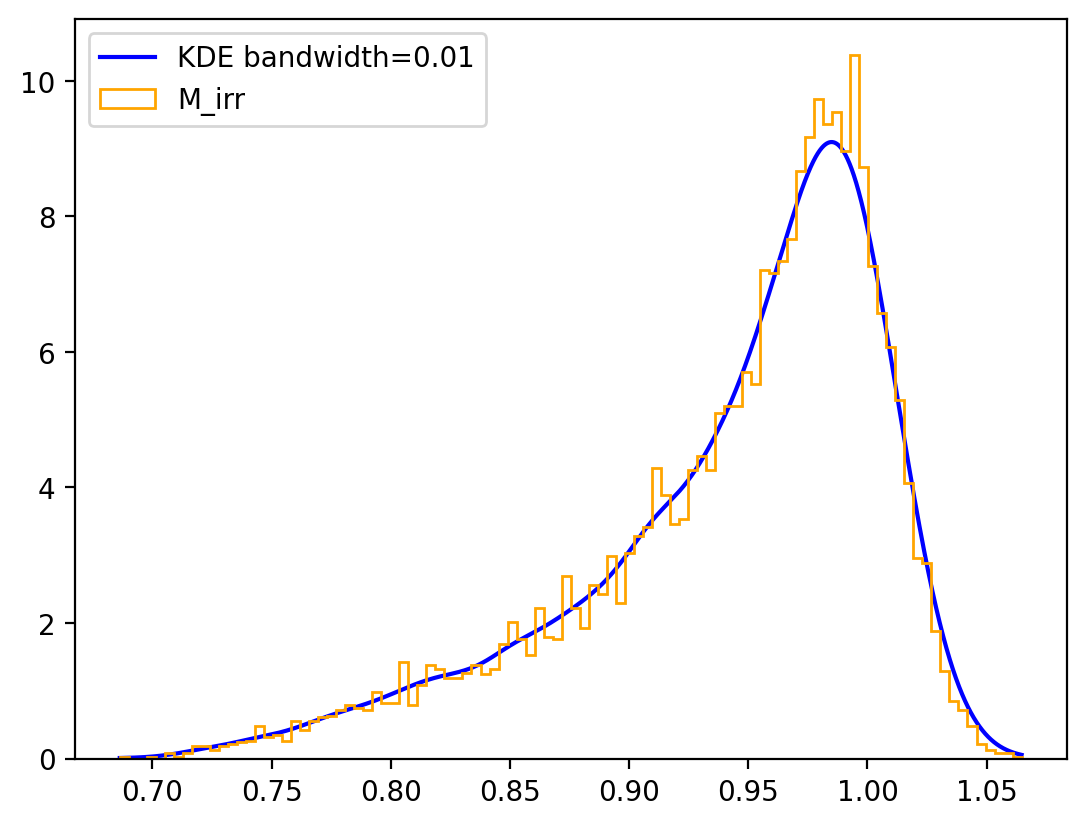

In [11]:
xgrid = np.linspace(M_irr.min(),M_irr.max(),N)

PDF = kde_sklearn(M_irr,bandwidth=0.01,kernel="gaussian")

plt.plot(xgrid,PDF, color='blue', label='KDE bandwidth=0.01') 
plt.hist(M_irr,bins=100,histtype='step',density=True, color='orange',label='M_irr');
plt.legend()

With different badwidth values

100%|████████████████████████████████████████████████████████████████████| 3/3 [00:16<00:00,  5.40s/it]


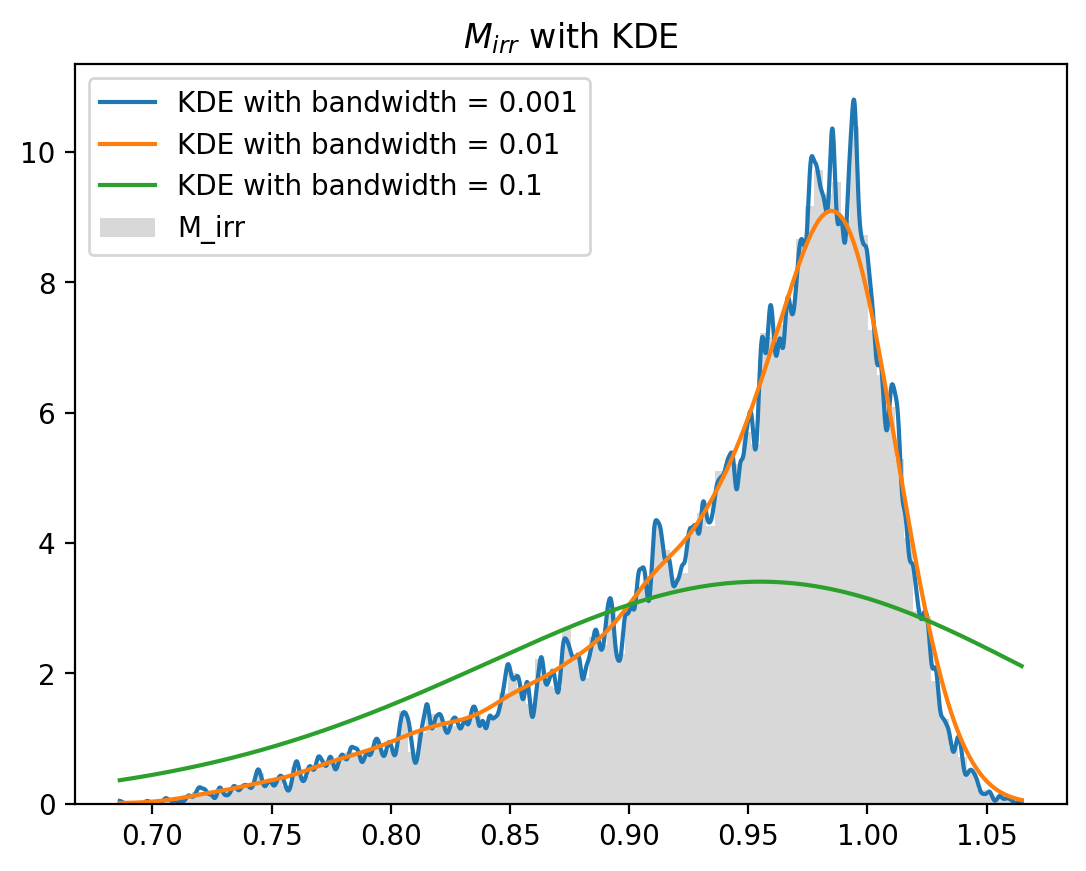

In [12]:
for bandwidth in tqdm([0.001, 0.01, 0.1]):
    PDF_M_irr = kde_sklearn(M_irr,bandwidth=bandwidth,kernel="gaussian")
    plt.plot(xgrid, PDF_M_irr,  label='KDE with bandwidth = '+str(bandwidth))

plt.hist(M_irr,bins=100,density=True, color='grey',alpha=0.3, label='M_irr');
plt.title(r'$M_{irr}$ with KDE')
plt.legend()
plt.show()

- too small bandwidth means the kernel is narrow and the KDE reconstruction captures too many details (blue line)
- too large bandwidth means the kernel is wide and the KDE reconstruction is poor, not capturing the true distribution (green line)

Now I would like to check the behavior of the distribution for different sigmas: I compute the KS distances

In [13]:
sigma=np.logspace(-5,5,20)
D_M=[]
D_f = []

chi = np.random.uniform(0,1,N)
F = f(chi)
for S in sigma:

    M=np.random.normal(loc=mu,scale=S,size=N)

    D_M.append(scipy.stats.ks_2samp(M, M*F))
    D_f.append(scipy.stats.ks_2samp(F, M*F))

ksM= np.array(D_M)
ksf= np.array(D_f)

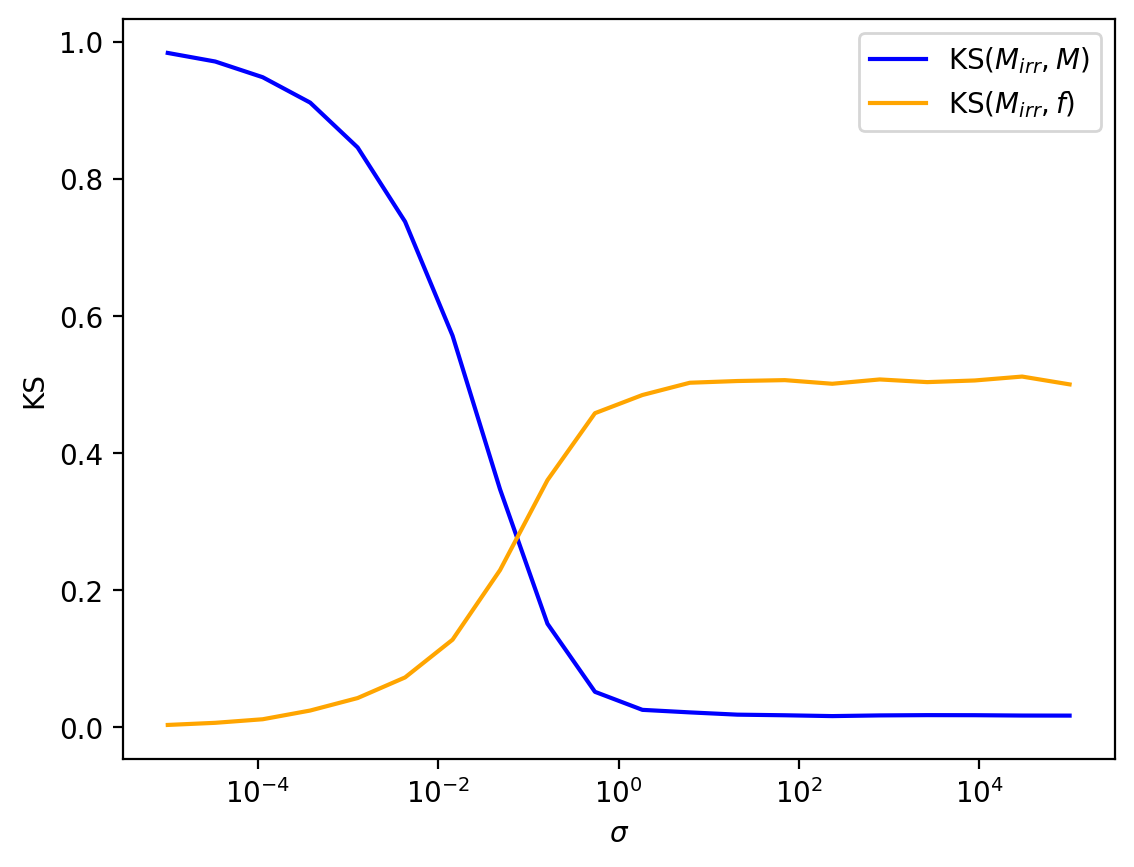

In [14]:
plt.plot(sigma,ksM[:,0],color='blue', label="KS$(M_{irr}, M)$")
plt.plot(sigma,ksf[:,0],color='orange', label="KS$(M_{irr}, f)$")
plt.semilogx()
plt.xlabel(r"$\sigma$")
plt.ylabel('KS')
plt.legend();

It shows that:
- for small sigmas, the KS distance between M_irr and f is small (tends to zero), so the M_irr distribution for small sigma is similar to the f distribution
- for big sigmas, the KS distance between M_irr and M is small (tends to zero), so the M_irr distribution for big sigma is similar to the mass distribution.

Now plot the semi-analytic function

In [15]:
mean = 1
sigma = 0.001 #small sigma -> similar to f

x = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N)

def integrand(f,x):
    return (np.sqrt(2/np.pi) / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/np.sqrt(1 - f**2) / f

Mirr_pdf = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/(2**0.5),1)[0] for xt in x]

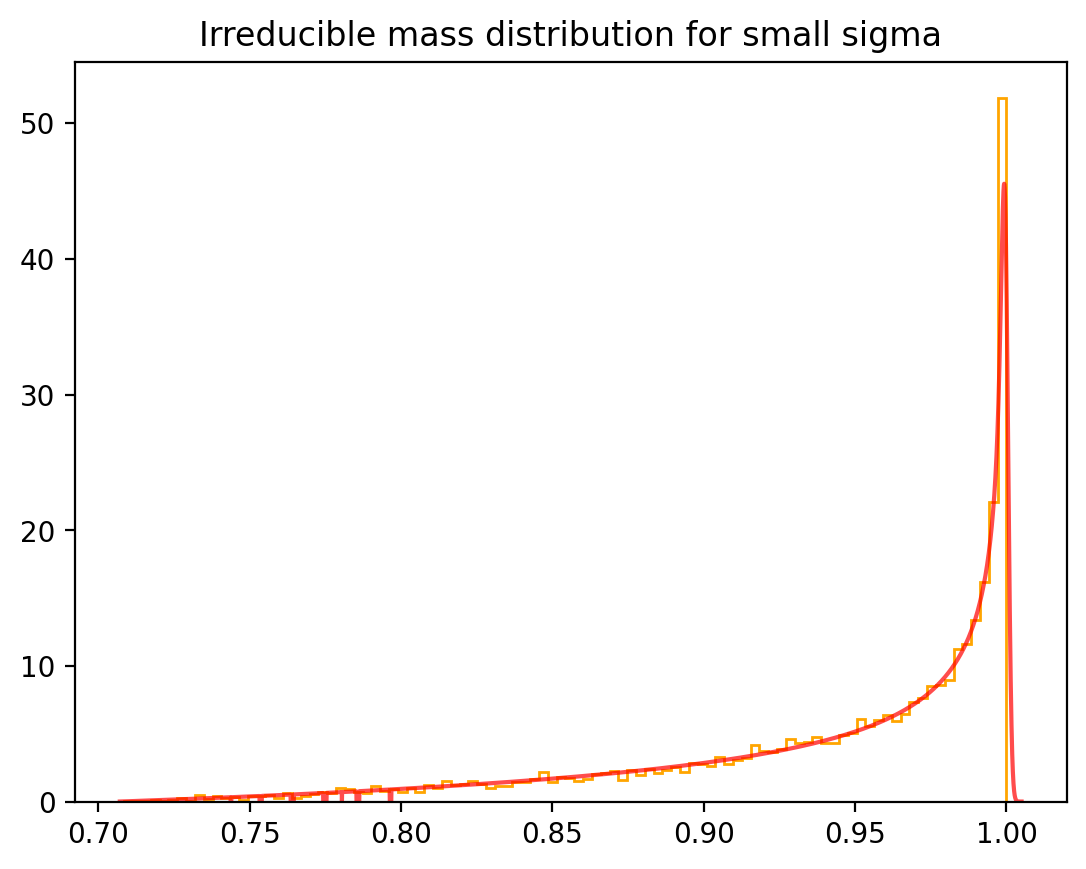

In [16]:
chi = np.random.uniform(0,1,N)

littlef = f(chi)
plt.hist(littlef,density=True,histtype='step', bins=100,color='orange')

plt.plot(x, Mirr_pdf, label='pdf',alpha=0.7, c='red')
plt.title('Irreducible mass distribution for small sigma');

In [17]:
mean = 1
sigma = 1 #big sigma -> similar to M

x = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N)

def integrand(f,x):
    return (np.sqrt(2/np.pi) / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/np.sqrt(1 - f**2) / f

Mirr_pdf = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/(2**0.5),1)[0] for xt in x]

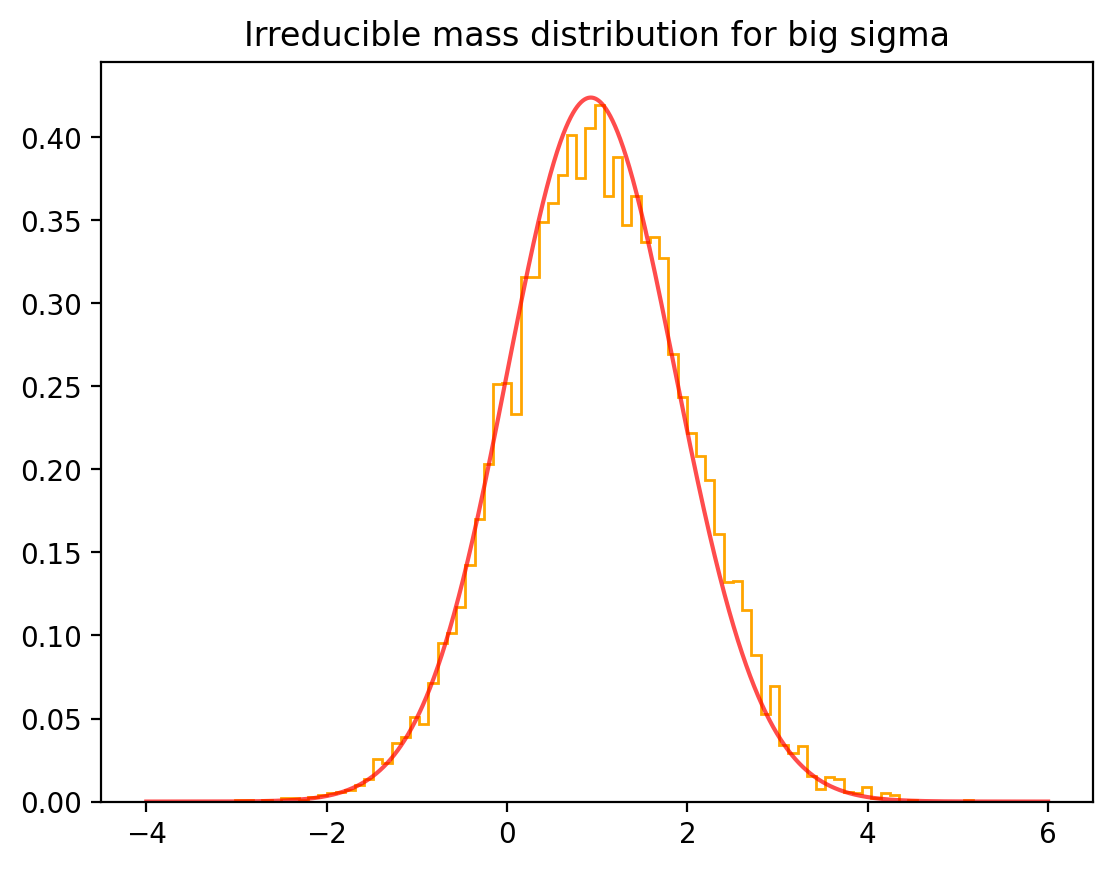

In [18]:
M=np.random.normal(loc=mu,scale=sigma,size=N)

plt.hist(M,density=True,histtype='step',bins=80,color='orange')

plt.plot(x, Mirr_pdf, alpha=0.7, label='pdf', c='red')
plt.title('Irreducible mass distribution for big sigma');

compare KDE result with the semi-analytic function and the data

In [19]:
mean = 1
sigma = 0.02  

x = np.linspace(M_irr.min(),M_irr.max(),N) 

def integrand(f,x):
    return (np.sqrt(2/np.pi) / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/np.sqrt(1 - f**2) / f

Mirr_pdf = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/(2**0.5),1)[0] for xt in x]

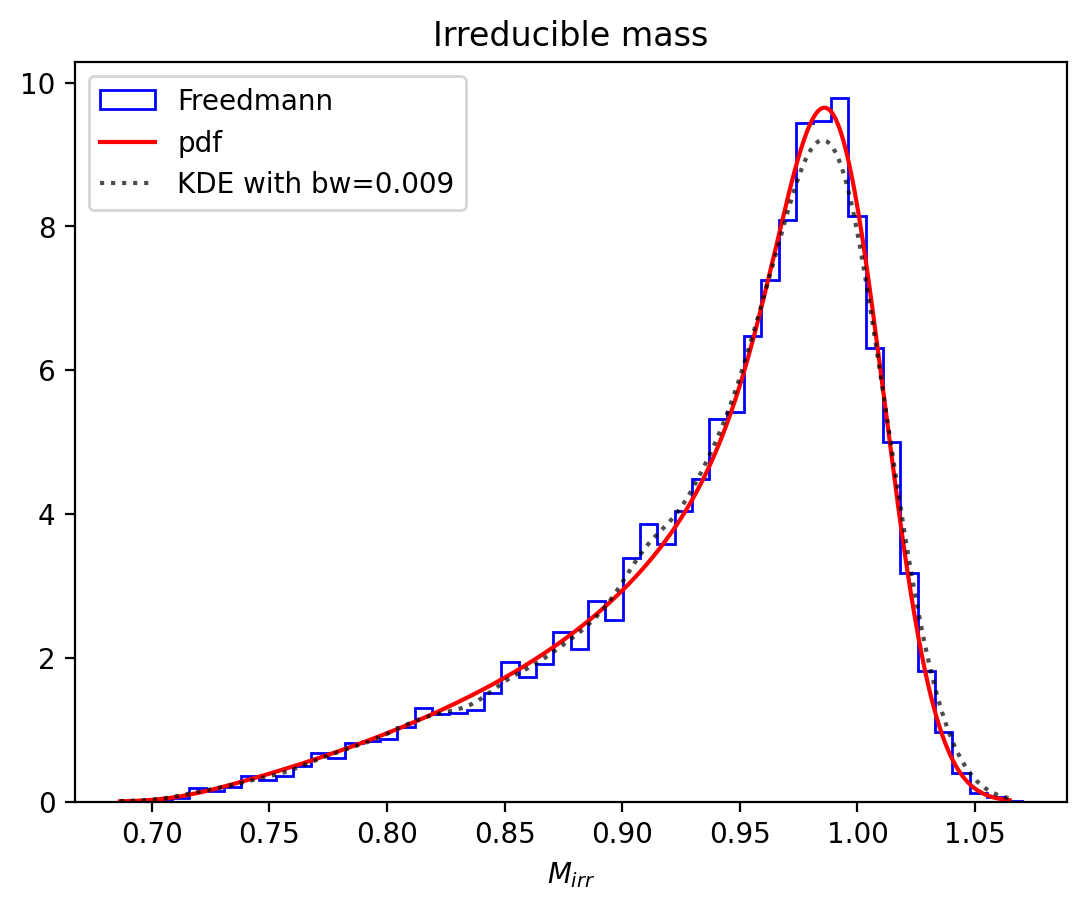

In [20]:
astropy.visualization.hist(M_irr, bins="freedman", histtype="step",density=True, color='blue', label='Freedmann')

plt.plot(x, Mirr_pdf, label='pdf', c='red')

kde_M_irr = kde_sklearn(M_irr,bandwidth=0.009,kernel="gaussian")
plt.plot(xgrid, kde_M_irr, label='KDE with bw='+str(0.009), ls='dotted',color='k', alpha=0.7)

plt.xlabel(r'$M_{irr}$')
plt.title('Irreducible mass')
plt.legend()
plt.show()